In [235]:
import requests
import json

# Параметры
BASE_URL = "https://financemarker.ru/api"
TOKEN = "w8rvn2i6xiexg2oj46gr"
COMPANIES = ["MOEX:ROSN", "MOEX:SIBN", "MOEX:SBER"]

def get_company_data(ticker):
    """Простая функция для получения данных компании"""
    url = f"{BASE_URL}/fm/v2/stocks/{ticker}"
    params = {
        "api_token": TOKEN,
        "include": "reports,ratios,shares,dividends,summary,operations"
        #include=reports%2C%20ratios%2C%20dividends%2C%20summary%2C%20operations&a
    }
    headers = {
        "accept": "application/json"
    }
    
    response = requests.get(url, params=params, headers=headers)
    
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Ошибка для {ticker}: {response.status_code}")
        return None

# # Тестируем компании
# for company in COMPANIES:
#     print(f"\nЗапрос данных для {company}:")
#     data = get_company_data(company)
    
#     if data:
#         print(f"Успешно получены данные для {company}")
#         # Здесь можно добавить обработку конкретных финансовых показателей
#         if 'reports' in data:
#             print(f"Количество финансовых отчетов: {len(data['reports'])}")
#     else:
#         print(f"Не удалось получить данные для {company}")

In [236]:
def get_moex_price(ticker):
    """
    Получение цены акции с Московской биржи
    """
    # URL для получения данных по акциям
    url = f"https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities/{ticker}.json"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        
        data = response.json()
        
        # Извлекаем данные из раздела marketdata
        market_data = data['marketdata']['data']
        if not market_data:
            print(f"Данные по тикеру {ticker} не найдены")
            return None
        
        # Берем первую запись (последние данные)
        last_price = market_data[0][4]  # LAST - последняя цена
        change = market_data[0][5]      # CHANGE - изменение
        open_price = market_data[0][7]  # OPEN - цена открытия
        
        return {
            'ticker': ticker,
            'last_price': last_price,
            'change': change,
            'open_price': open_price
        }
        
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе: {e}")
        return None

# Использование
ticker = "SIBN"
price_data = get_moex_price(ticker)
current_share_price = price_data['change']
print(current_share_price)
current_share_price = 490

None


In [237]:
sibn = get_company_data("MOEX:SIBN")

In [238]:
# print(sibn['operations'][-1])
cash_and_eq = sibn['reports'][-4]['cash_and_equiv']
print(sibn['reports'][-4]['cash_equiv_st_invesments'])

133065885


In [239]:
total_debt = sibn['reports'][-4]['total_debt']
number_shares = sibn['shares'][-4]['num']
print(number_shares)
#в свободном обращении 4.32% 

4741299639


In [240]:
#Step 1 calculate enterprise value 
# input from the data
# current share price 
# Shares outstanding (millions) - количество акций в обращении 
# Total debt 
# Cash and cash equivalents 
# Minority interest, non-controlling interest 

# Enterprise value = market cap + minority interest + net debt - cash 
market_cap = number_shares * current_share_price
enterprise_value = market_cap + total_debt - cash_and_eq
print(enterprise_value)

2324694886133


In [241]:
# Расчет ставки дисконтирования  
# Wacc = k_d * w_d * (1 - T) + k_e * w_e 
# k_d - average cost of the capital 
# w_d - realtive wegiht rented capital in company capital (rented_capital_rate)
# T - earning taxes rates
# k_e - average cost of the own company capital 
# W_e - relative weight of own capital (own_capital_rate)
own_captial_rate = market_cap/(market_cap + total_debt)
rented_capital_rate = 1 - own_captial_rate
assert rented_capital_rate > 0 
print(own_captial_rate)
print(rented_capital_rate)


0.9993420934647713
0.0006579065352286806


In [84]:
# CAPM
# Capital asset pricing model 
# Cost of equity = Rf+ Beta* (Rm — Rf) + Country premium = Rf+ Beta*ERP + Country premium
# Rf - no risk rate (average deposit rate here) ~13%
# Rm - Rf with stock market risk premium 
# Equity Risk Premium = 23.21% (ERP Duff&Phelps for stock market) https://www.wallstreetprep.com/knowledge/country-risk-premium/
# \beta (no debt beta) for SIBN = 0.51 
# Russia CRP = 18.21%	
# ERP = 23.21%
# Hamada formula (for leverage beta): \beta_leverage = \beta * (1 + (1 - t)D/E) t - tax rate (T), D - debt capital, E - equity
beta_sibn = 0.51
ERP = 0.2321
CRP = 0.1821
Rf = 0.13 
T = 0.70 # averaged tax rate 
beta_leverage = beta_sibn * (1 + (1 - T) * rented_capital_rate/own_captial_rate)
print(beta_leverage) 
equity_cost = Rf + beta_leverage * ERP + CRP 
print(equity_cost) 

0.5100000793109214
0.4304710184080649


In [85]:
# To account cost of the rented capital we need to take rate of every debt and check repayment amount 
# Need full debt structure 
cost_of_rented_capital = sibn['reports'][-4]['interest_expense']/total_debt

# rented capital calculated as ebt = ebit - interest |> 
ebt = sibn['reports'][-4]['ebit'] - sibn['reports'][-4]['interest_income']
taxes_payment = sibn['reports'][-4]['earnings_wo_tax'] - sibn['reports'][-4]['earnings']
taxes = taxes_payment/ebt
print(taxes)

0.3402210830767359


In [86]:
# Wacc = k_d * w_d * (1 - T) + k_e * w_e 
# k_d - average cost of rented capital 
# w_d - realtive wegiht rented capital in company capital (rented_capital_rate)
# T - earning taxes rates
# k_e - average cost of the own company capital 
# W_e - relative weight of own capital (own_capital_rate)
wacc = cost_of_rented_capital * rented_capital_rate * (1 - taxes) + equity_cost * own_captial_rate
print(wacc)

0.4304708219992486


In [87]:
da = sibn['reports'][-4]['ebitda'] - sibn['reports'][-4]['ebit']

In [90]:
ufcf = sibn['reports'][-4]['ebit'] - taxes_payment + da - sibn['reports'][-4]['capex']
print(ufcf)

394977


In [91]:
sibn['reports'][-4]['revenue']

3855707

In [225]:
# for el in sibn['reports']:
#     if el['type'] == 'РСБУ' and el['period'] == '9M':
#         print(el['year'])

In [214]:
# stats
stats = []
for el in sibn['reports']:
    if el['type'] == 'МСФО' and el['period'] == 'Y':
        stats.append(el)

In [234]:
print(stats[-1]['cost_of_sales'])

None


In [226]:
stats[-1].keys()

dict_keys(['accounts_payable', 'accounts_receivable', 'amount', 'capex', 'cash_and_equiv', 'cash_equiv_st_invesments', 'cash_paid_for_interest', 'cash_paid_for_tax', 'cff', 'cfi', 'cfo', 'changed_at', 'code', 'commission_expense', 'commission_income', 'commission_net', 'cost_of_sales', 'cur_long_debt', 'cur_long_lease', 'curr', 'current_assets', 'current_debt', 'current_lease', 'current_liabilities', 'depr_depl_amort', 'earnings', 'earnings_comprehensive', 'earnings_comprehensive_stock_holders', 'earnings_continuing_operations', 'earnings_ps', 'earnings_stock_holders', 'earnings_wo_tax', 'ebit', 'ebitda', 'ebitda_adjusted', 'ebitda_adjusted_ps', 'ebitda_ps', 'equity', 'equity_ps', 'equity_stock_holders', 'exchange', 'fcf', 'fcf_adjusted', 'fcf_adjusted_ps', 'fcf_ps', 'ffo', 'goodwill', 'goodwill_intangible_assets', 'gross_profit', 'intangible_assets', 'intangibles_purchase', 'interest_expense', 'interest_income', 'interest_net', 'inventories', 'issuance_of_debt', 'link', 'link_press', 

In [215]:
import numpy as np 
import matplotlib.pyplot as plt
earnings_array = np.zeros((len(stats), 4))
for id, el in enumerate(stats): 
    # print(el['year'])
    earnings_array[id, 0] = el['year']
    earnings_array[id, 1] = el['revenue']
    earnings_array[id, 2] = el['ebitda']

In [216]:
#let's extrapolate it with mse and take negative coeffitient based on negative change 2024-2025 9 month revenue 
# find 2024-2025 
nine_month_reports = []
for el in sibn['reports']: 
    if el['type'] == 'РСБУ' and el['period'] == '9M' and (el['year'] == 2025 or el['year'] == 2024):
        print(el['year'])
        nine_month_reports.append(el)
print(len(nine_month_reports))

2024
2025
2


In [217]:
y_to_y_change = (nine_month_reports[1]['revenue'] - nine_month_reports[0]['revenue'])/nine_month_reports[0]['revenue']
print(y_to_y_change)

-0.23317996765621674


In [218]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
earnings_array[:, 0].reshape(-1, 1)
reg.fit(earnings_array[:, 0].reshape(-1, 1), earnings_array[:, 1])
forecast = reg.predict([[2025]])
print(forecast[0])

3893198.67032969


In [219]:
revenue_growth = np.vstack((earnings_array[:, 0:2], np.array([2025, forecast[0]])))
revenue_growth[-1, 1] = earnings_array[-1, 1] * (1 + y_to_y_change)  
print(revenue_growth[-1, 1])

3143738.221160067


In [221]:
revenue_growth[-2, 1]

4099708.0

In [209]:
transport = 895453 # transport  
commodity = 298208 #commodity 
#Выручка - (Покупка сырья + Транспорт)
gross_profit_margin = (earnings_array[-2, 1] - (transport + commodity))/earnings_array[-2, 1]
print(gross_profit_margin)
print()

0.7088424346319299



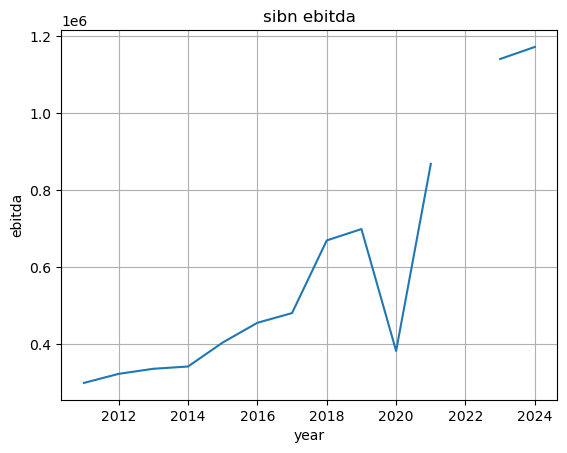

In [224]:
plt.plot(earnings_array[:, 0], earnings_array[:, 2])
plt.xlabel('year')
plt.ylabel('ebitda')
plt.title('sibn ebitda')
plt.grid(True)